['-.', '--', '-.', ':', '--', '-', '-.', ':', '-', '-.', '--', '-.', ':', '--', '-', '-.', ':', '-']


/tmp/ipykernel_2881086/1590865201.py:75: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i + 1, medians[i], f'{medians[i]:.2f}', ha='center', va='bottom', color='black')


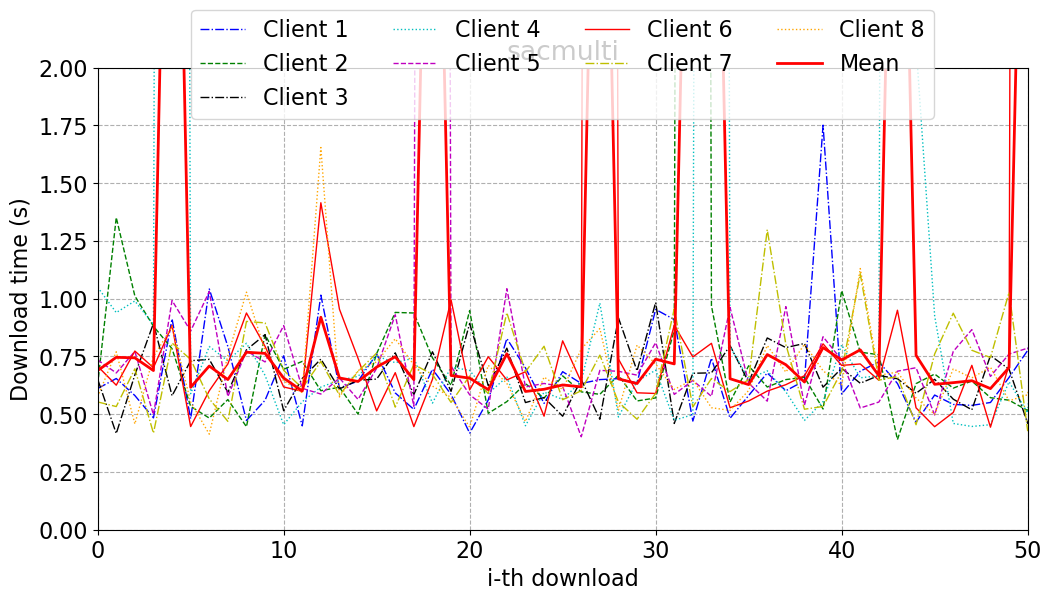

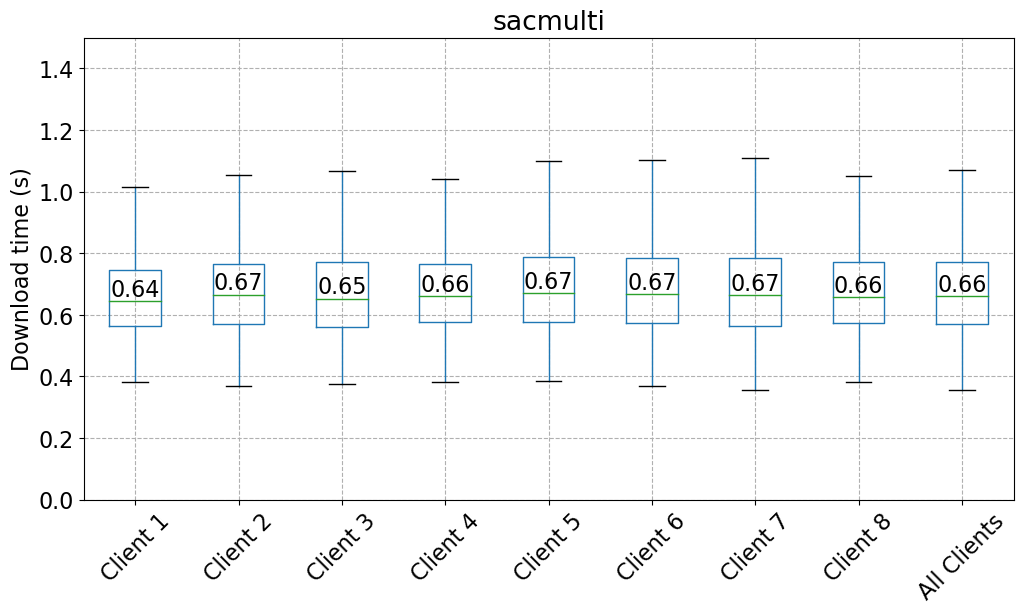

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Define the number of files to read
clt = 8
sch = 'sacmulti'

# Generate file paths based on the number of files (clt)
file_paths = [f'../output/new50-{clt}-vary/none-{clt}-1MB-0-0-50-15-10-0.9-{sch}-result{i+3}.csv' for i in range(clt)]

# Read all the files into separate dataframes
data_frames = [pd.read_csv(file, names=['data', 'timestamp']) for file in file_paths]

# Convert the 'data' column to numeric, handling any potential non-numeric values
for df in data_frames:
    df['data'] = pd.to_numeric(df['data'], errors='coerce')

# Extract the 'data' column from each DataFrame and slice from the 100th row onwards
data_frames_1 = [df['data'][1:] for df in data_frames]

# Combine the 'data' columns into a single DataFrame
combined_data = pd.DataFrame({f'file{i+1}': df.reset_index(drop=True) for i, df in enumerate(data_frames_1)})
combined_data = combined_data / 1000  # Convert to seconds

# Calculate the mean of the columns at each point
combined_data['mean'] = combined_data.mean(axis=1)

# Create a new DataFrame containing all values from other columns except 'mean'
all_clients = pd.DataFrame(combined_data.drop(columns=['mean']).values.flatten(), columns=['all_clients'])

# Plot the combined data
plt.rcParams.update({'font.size': 16, 'font.family': 'sans-serif'})
plt.figure(figsize=(12, 6))

# Generate legend names, line styles, and colors dynamically based on the number of files (clt)
legend_names = [f'Client {i+1}' for i in range(clt)] + ['Mean']
line_styles = ['-.', '--', '-.', ':', '--', '-', '-.', ':', '-'] * (clt // 8 + 1) 
colors = ['b', 'g', 'k', 'c', 'm', 'r', 'y', 'orange', 'r'] * (clt // 8 + 1) 
line_widths = [1] * clt + [2]
print(line_styles)

for column, name, style, color, lw in zip(combined_data.columns, legend_names, line_styles, colors, line_widths):
    plt.plot(combined_data[column], label=name, linestyle=style, color=color, linewidth=lw)

plt.xlabel('i-th download')
plt.ylabel('Download time (s)')
plt.title(f'{sch}')
plt.xlim(0, 50)
plt.ylim(0, 2)
plt.legend()
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=clt // 2)
plt.grid(True, linestyle="--")

# Define custom x-tick labels
x_tick_labels = [f'Client {i+1}' for i in range(clt)] + ['All Clients']

# Create a new DataFrame for the boxplot
boxplot_data = combined_data.drop(columns=['mean']).copy()
boxplot_data = pd.concat([boxplot_data, all_clients], axis=1)

# Plot the boxplot
plt.figure(figsize=(12, 6))
boxplot = boxplot_data.boxplot(patch_artist=False, showfliers=False)
plt.ylabel('Download time (s)')
plt.title(f'{sch}')
plt.grid(True, linestyle="--")

# Set custom x-tick labels and rotate them 45 degrees
plt.xticks(ticks=range(1, len(x_tick_labels) + 1), labels=x_tick_labels, rotation=45)
plt.ylim(0, 1.5)

medians = boxplot_data.median()
for i in range(len(medians)):
    plt.text(i + 1, medians[i], f'{medians[i]:.2f}', ha='center', va='bottom', color='black')

plt.show()
